In [70]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import nearest_points
from sklearn.cluster import KMeans
import shap
from sklearn.inspection import PartialDependenceDisplay
import json

# DATA PREPARATION

In [71]:
DATASETS_PATH = "../Datasets/"

In [72]:
income = pd.read_csv(DATASETS_PATH + 'Average personal income.csv', sep=';')
green = pd.read_csv(DATASETS_PATH + 'green-spaces.csv')
pollution = pd.read_csv(DATASETS_PATH + 'predicted_air_pollution.csv')

In [73]:
income = income[['Neighbourhood', '2022']].rename(columns={'2022': 'Income_2022'})

In [74]:
income['Income_2022'] = (
    income['Income_2022']
    .replace('.', np.nan)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

In [75]:
income = income.dropna(subset=['Income_2022'])

In [76]:
green['NEIGHBOURHOOD'] = green['NEIGHBOURHOOD'].str.strip()
green_grouped = green.groupby('NEIGHBOURHOOD').agg(
    total_green_space=('SURFACE_AREA', 'sum'),
    num_green_areas=('SURFACE_AREA', 'count'),
    avg_green_area=('SURFACE_AREA', 'mean')
).reset_index()

In [77]:
pollution['Neighbourhood'] = pollution['Neighbourhood'].str.strip()
pollution_grouped = pollution.groupby('Neighbourhood').agg({
    'PM2.5_mean': 'mean',
    'PM10_mean': 'mean',
    'NO2_mean': 'mean',
    'LAT': 'first',
    'LON': 'first'
}).reset_index()

In [78]:
# the giga dataset
df = income.merge(pollution_grouped, left_on='Neighbourhood', right_on='Neighbourhood', how='inner')
df = df.merge(green_grouped, left_on='Neighbourhood', right_on='NEIGHBOURHOOD', how='inner')

In [79]:
df

,Neighbourhood,Income_2022,PM2.5_mean,PM10_mean,NO2_mean,LAT,LON,NEIGHBOURHOOD,total_green_space,num_green_areas,avg_green_area
0,Achtse Barrier-Gunterslaer,39.2,12.839486,18.556209,21.366210,51.480354,5.447328,Achtse Barrier-Gunterslaer,141028.292,506,278.712040
1,Achtse Barrier-Hoeven,37.6,12.005384,17.808110,21.935153,51.490450,5.445992,Achtse Barrier-Hoeven,132439.353,424,312.356965
2,Achtse Barrier-Spaaihoef,41.3,11.520968,17.415388,22.413961,51.491486,5.439192,Achtse Barrier-Spaaihoef,193523.418,390,496.213892
3,Barrier,34.1,13.505681,19.309259,21.406309,51.460771,5.459137,Barrier,16742.924,173,96.779908
4,Bennekel-Oost,30.6,12.762678,19.159394,19.199835,51.419828,5.463448,Bennekel-Oost,179586.744,450,399.081653
...,...,...,...,...,...,...,...,...,...,...,...
84,Woenselse Heide,32.3,13.355322,19.197064,20.164429,51.480006,5.463207,Woenselse Heide,107085.237,649,165.000365
85,Woenselse Watermolen,49.6,13.625494,19.534181,21.288321,51.450066,5.480106,Woenselse Watermolen,29484.643,135,218.404763
86,Woensel-West,31.1,13.352990,18.971660,22.047907,51.455354,5.456184,Woensel-West,84865.966,750,113.154621
87,Zandrijk,46.5,12.931337,18.995745,23.869586,51.451241,5.393055,Zandrijk,46064.251,545,84.521561


In [80]:
df = df.drop(columns=['NEIGHBOURHOOD'])

# MODELLING

In [81]:
features = ['total_green_space', 'num_green_areas', 'avg_green_area', 'PM2.5_mean', 'PM10_mean', 'NO2_mean']
X = df[features]
y = df['Income_2022']

In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [84]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=100),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

In [85]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'\nModel: {name}')
    print('R2 Score:', r2_score(y_test, y_pred))
    print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))


Model: LinearRegression
R2 Score: -0.18724308862762395
RMSE: 18.24256359955205

Model: Ridge
R2 Score: -0.1783808798526132
RMSE: 18.174350006021484

Model: Lasso
R2 Score: -0.17885249828500083
RMSE: 18.17798656409787

Model: RandomForest
R2 Score: 0.05560231420534212
RMSE: 16.270222837031653

Model: GradientBoosting
R2 Score: 0.01922920107987336
RMSE: 16.58058339834885

Model: SVR
R2 Score: -0.08733622339763514
RMSE: 17.458140011273642

Model: KNN
R2 Score: -0.12040547426818238
RMSE: 17.721629596500303


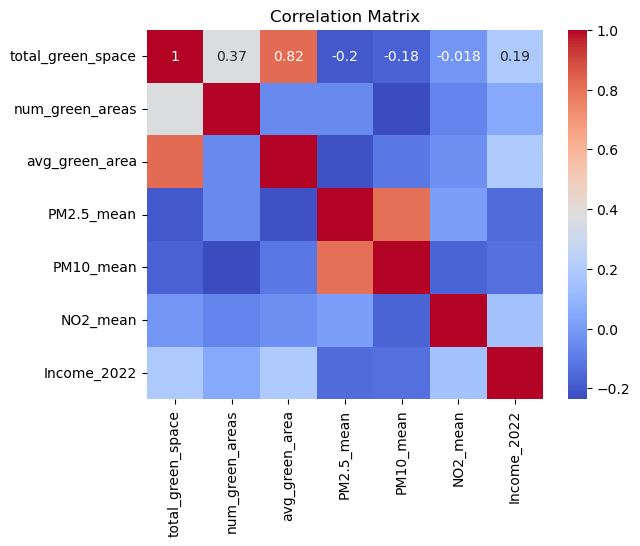

In [86]:
corr = df[features + ['Income_2022']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [87]:
green['geometry'] = green.apply(lambda row: Point(row['LON'], row['LAT']), axis=1)
green_gdf = gpd.GeoDataFrame(green, geometry='geometry', crs='EPSG:4326')

In [88]:
neigh_coords = pollution[['Neighbourhood', 'LAT', 'LON']].drop_duplicates()
neigh_coords['geometry'] = neigh_coords.apply(lambda row: Point(row['LON'], row['LAT']), axis=1)
neigh_gdf = gpd.GeoDataFrame(neigh_coords, geometry='geometry', crs='EPSG:4326')

In [89]:
reen_gdf = green_gdf.to_crs(epsg=28992)
neigh_gdf = neigh_gdf.to_crs(epsg=28992)

In [90]:
def get_nearest_distance(row, green_spaces):
    nearest_geom = green_spaces.geometry.unary_union
    nearest = nearest_points(row.geometry, nearest_geom)[1]
    return row.geometry.distance(nearest)

In [91]:
neigh_gdf['distance_to_green_space_m'] = neigh_gdf.apply(
    lambda row: get_nearest_distance(row, green_gdf), axis=1
)

C:\Users\User\AppData\Local\Temp\ipykernel_5328\4294246231.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  nearest_geom = green_spaces.geometry.unary_union
c:\Users\User\anaconda3\Lib\site-packages\shapely\set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
c:\Users\User\anaconda3\Lib\site-packages\shapely\linear.py:236: RuntimeWarning: invalid value encountered in shortest_line
  return lib.shortest_line(a, b, **kwargs)


In [92]:
df = df.merge(neigh_gdf[['Neighbourhood', 'distance_to_green_space_m']], on='Neighbourhood', how='left')

In [93]:
df = df.merge(pollution, on='Neighbourhood', how='left')

In [94]:
df

,Neighbourhood,Income_2022,PM2.5_mean_x,PM10_mean_x,NO2_mean_x,LAT_x,LON_x,total_green_space,num_green_areas,avg_green_area,distance_to_green_space_m,LAT_y,LON_y,PM1_mean,PM2.5_mean_y,PM10_mean_y,NO2_mean_y
0,Achtse Barrier-Gunterslaer,39.2,12.839486,18.556209,21.366210,51.480354,5.447328,141028.292,506,278.712040,419262.500776,51.480354,5.447328,10.369946,12.839486,18.556209,21.366210
1,Achtse Barrier-Hoeven,37.6,12.005384,17.808110,21.935153,51.490450,5.445992,132439.353,424,312.356965,420266.335248,51.490450,5.445992,9.568389,12.005384,17.808110,21.935153
2,Achtse Barrier-Spaaihoef,41.3,11.520968,17.415388,22.413961,51.491486,5.439192,193523.418,390,496.213892,420194.163590,51.491486,5.439192,9.136034,11.520968,17.415388,22.413961
3,Barrier,34.1,13.505681,19.309259,21.406309,51.460771,5.459137,16742.924,173,96.779908,417563.016521,51.460771,5.459137,10.919672,13.505681,19.309259,21.406309
4,Bennekel-Oost,30.6,12.762678,19.159394,19.199835,51.419828,5.463448,179586.744,450,399.081653,413477.505780,51.419828,5.463448,10.117878,12.762678,19.159394,19.199835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,Woenselse Heide,32.3,13.355322,19.197064,20.164429,51.480006,5.463207,107085.237,649,165.000365,419647.777635,51.480006,5.463207,10.744908,13.355322,19.197064,20.164429
85,Woenselse Watermolen,49.6,13.625494,19.534181,21.288321,51.450066,5.480106,29484.643,135,218.404763,417027.251562,51.450066,5.480106,11.031429,13.625494,19.534181,21.288321
86,Woensel-West,31.1,13.352990,18.971660,22.047907,51.455354,5.456184,84865.966,750,113.154621,416927.731123,51.455354,5.456184,10.855891,13.352990,18.971660,22.047907
87,Zandrijk,46.5,12.931337,18.995745,23.869586,51.451241,5.393055,46064.251,545,84.521561,414839.546904,51.451241,5.393055,10.431848,12.931337,18.995745,23.869586


In [95]:
features = [
    'total_green_space',
    'num_green_areas',
    'avg_green_area',
    'PM2.5_mean_x',
    'PM10_mean_x',
    'NO2_mean_x',
    'distance_to_green_space_m'
]
X = df[features]
y = df['Income_2022']

In [96]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [97]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=100),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

In [98]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nModel: {name}")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")


Model: LinearRegression
R² Score: -0.2092
RMSE: 18.41

Model: Ridge
R² Score: -0.2058
RMSE: 18.38

Model: Lasso
R² Score: -0.2199
RMSE: 18.49

Model: RandomForest
R² Score: 0.0201
RMSE: 16.57

Model: GradientBoosting
R² Score: -0.0911
RMSE: 17.49

Model: SVR
R² Score: 0.0340
RMSE: 16.46

Model: KNN
R² Score: -0.2270
RMSE: 18.55


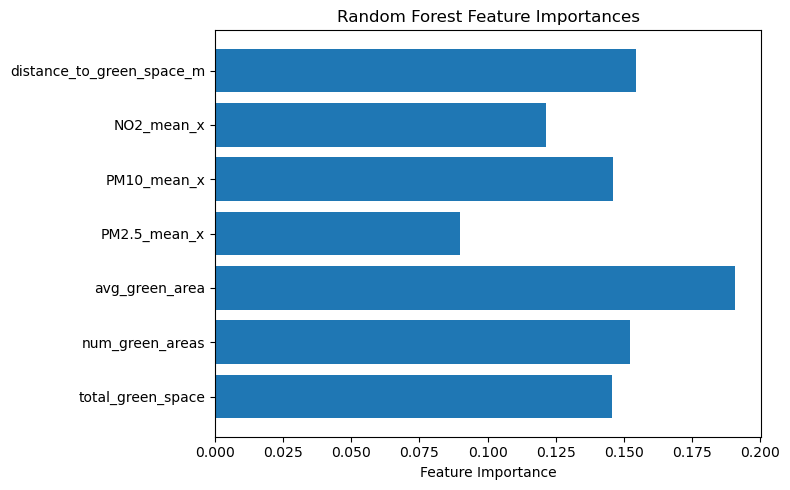

In [99]:
rf_model = models['RandomForest']
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_names = X.columns if isinstance(X, pd.DataFrame) else features

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [100]:
features = [
    'PM2.5_mean_x',
    'PM10_mean_x',
    'NO2_mean_x',
]
X = df[features]
y = df['Income_2022']

In [101]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [102]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', C=100),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

In [103]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"\nModel: {name}")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")


Model: LinearRegression
R² Score: -0.2337
RMSE: 18.60

Model: Ridge
R² Score: -0.2345
RMSE: 18.60

Model: Lasso
R² Score: -0.2391
RMSE: 18.64

Model: RandomForest
R² Score: -0.2935
RMSE: 19.04

Model: GradientBoosting
R² Score: -0.3615
RMSE: 19.54

Model: SVR
R² Score: -0.5154
RMSE: 20.61

Model: KNN
R² Score: -0.2405
RMSE: 18.65


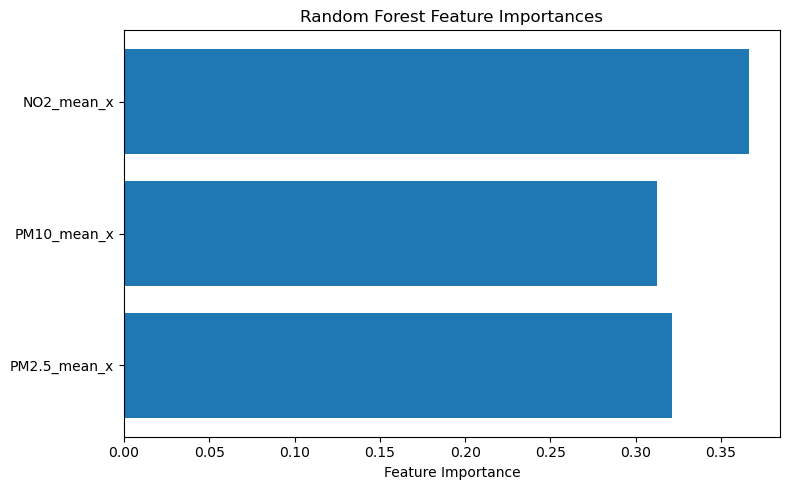

In [104]:
rf_model = models['RandomForest']
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
feature_names = X.columns if isinstance(X, pd.DataFrame) else features

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [105]:
features = [
    'total_green_space',
    'num_green_areas',
    'avg_green_area',
    'PM2.5_mean_x',
    'PM10_mean_x',
    'NO2_mean_x',
    'distance_to_green_space_m'
]
X = df[features]
y = df['Income_2022']

In [123]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# CLUSTERING ATTEMPT

In [124]:
cluster_features = [
    'Income_2022',
    'PM2.5_mean_x',
    'NO2_mean_x',
    'distance_to_green_space_m',
    'total_green_space',
    'avg_green_area'
]

In [125]:
X_cluster = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [126]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

c:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [127]:
df

,Neighbourhood,Income_2022,PM2.5_mean_x,PM10_mean_x,NO2_mean_x,LAT_x,LON_x,total_green_space,num_green_areas,avg_green_area,distance_to_green_space_m,LAT_y,LON_y,PM1_mean,PM2.5_mean_y,PM10_mean_y,NO2_mean_y,cluster
0,Achtse Barrier-Gunterslaer,39.2,12.839486,18.556209,21.366210,51.480354,5.447328,141028.292,506,278.712040,419262.500776,51.480354,5.447328,10.369946,12.839486,18.556209,21.366210,0
1,Achtse Barrier-Hoeven,37.6,12.005384,17.808110,21.935153,51.490450,5.445992,132439.353,424,312.356965,420266.335248,51.490450,5.445992,9.568389,12.005384,17.808110,21.935153,2
2,Achtse Barrier-Spaaihoef,41.3,11.520968,17.415388,22.413961,51.491486,5.439192,193523.418,390,496.213892,420194.163590,51.491486,5.439192,9.136034,11.520968,17.415388,22.413961,2
3,Barrier,34.1,13.505681,19.309259,21.406309,51.460771,5.459137,16742.924,173,96.779908,417563.016521,51.460771,5.459137,10.919672,13.505681,19.309259,21.406309,0
4,Bennekel-Oost,30.6,12.762678,19.159394,19.199835,51.419828,5.463448,179586.744,450,399.081653,413477.505780,51.419828,5.463448,10.117878,12.762678,19.159394,19.199835,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,Woenselse Heide,32.3,13.355322,19.197064,20.164429,51.480006,5.463207,107085.237,649,165.000365,419647.777635,51.480006,5.463207,10.744908,13.355322,19.197064,20.164429,0
85,Woenselse Watermolen,49.6,13.625494,19.534181,21.288321,51.450066,5.480106,29484.643,135,218.404763,417027.251562,51.450066,5.480106,11.031429,13.625494,19.534181,21.288321,0
86,Woensel-West,31.1,13.352990,18.971660,22.047907,51.455354,5.456184,84865.966,750,113.154621,416927.731123,51.455354,5.456184,10.855891,13.352990,18.971660,22.047907,2
87,Zandrijk,46.5,12.931337,18.995745,23.869586,51.451241,5.393055,46064.251,545,84.521561,414839.546904,51.451241,5.393055,10.431848,12.931337,18.995745,23.869586,2


c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\User\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

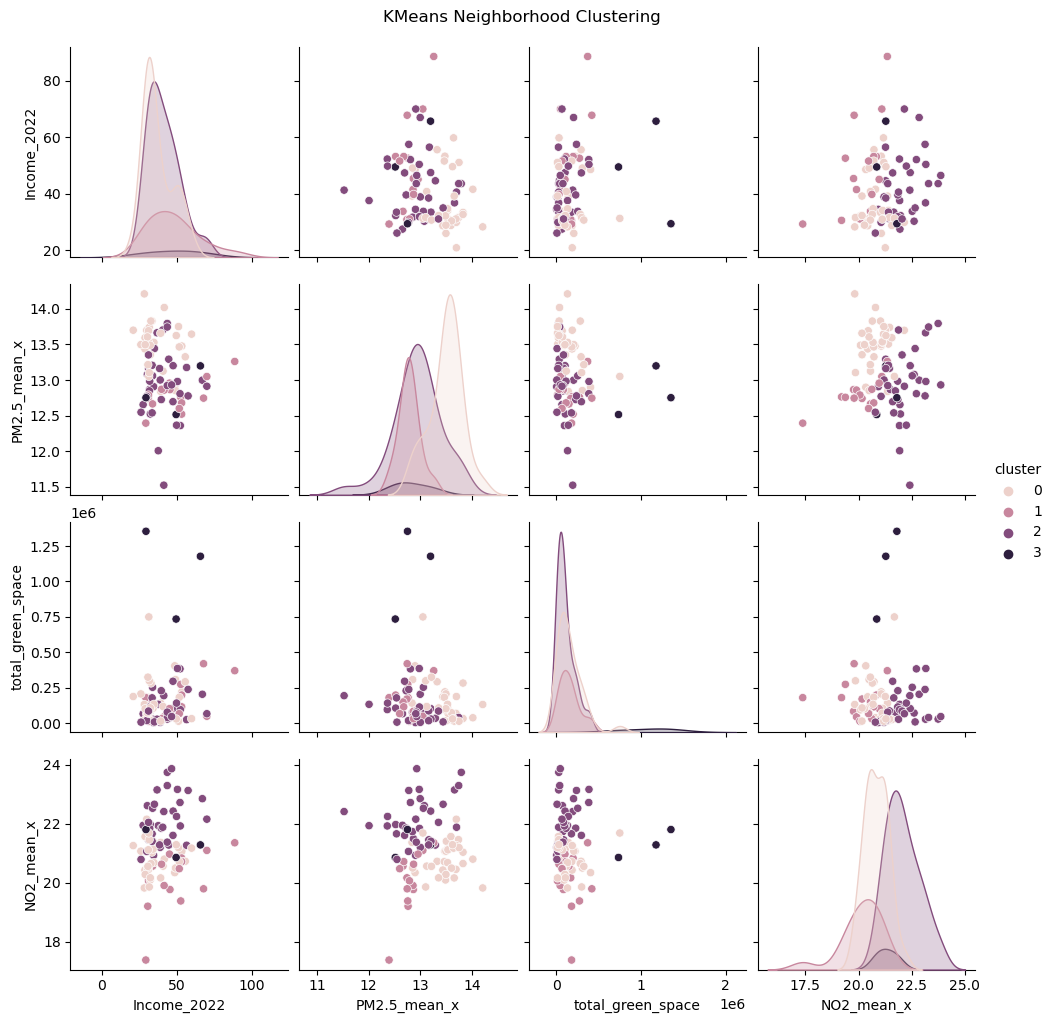

In [128]:
sns.pairplot(df, vars=['Income_2022', 'PM2.5_mean_x', 'total_green_space', 'NO2_mean_x'], hue='cluster')
plt.suptitle("KMeans Neighborhood Clustering", y=1.02)
plt.show()

In [129]:
buurten_df = pd.read_csv(DATASETS_PATH + '/Raw Datasets/buurten.csv', delimiter=';')

In [130]:
def parse_geo_shape(geo_str):
    try:
        return json.loads(geo_str.replace('""', '"'))
    except:
        return None

In [131]:
from shapely.geometry import shape
import contextily as ctx

buurten_df['geometry'] = buurten_df['geo_shape'].apply(lambda x: shape(parse_geo_shape(x)) if parse_geo_shape(x) else None)
buurten_gdf = gpd.GeoDataFrame(
    buurten_df,
    geometry='geometry',
    crs='EPSG:4326'
)

In [132]:
buurten_gdf['BUURTNAAM'] = buurten_gdf['BUURTNAAM'].str.strip()
df['Neighbourhood'] = df['Neighbourhood'].str.strip()

In [133]:
merged_gdf = buurten_gdf.merge(df, left_on='BUURTNAAM', right_on='Neighbourhood', how='inner')

In [134]:
merged_gdf = merged_gdf.rename(columns={'geometry_y': 'geometry'})

In [135]:
merged_gdf = merged_gdf.set_geometry('geometry')

if merged_gdf.crs is None:
	merged_gdf = merged_gdf.set_crs(epsg=4326)
merged_gdf_3857 = merged_gdf.to_crs(epsg=3857)

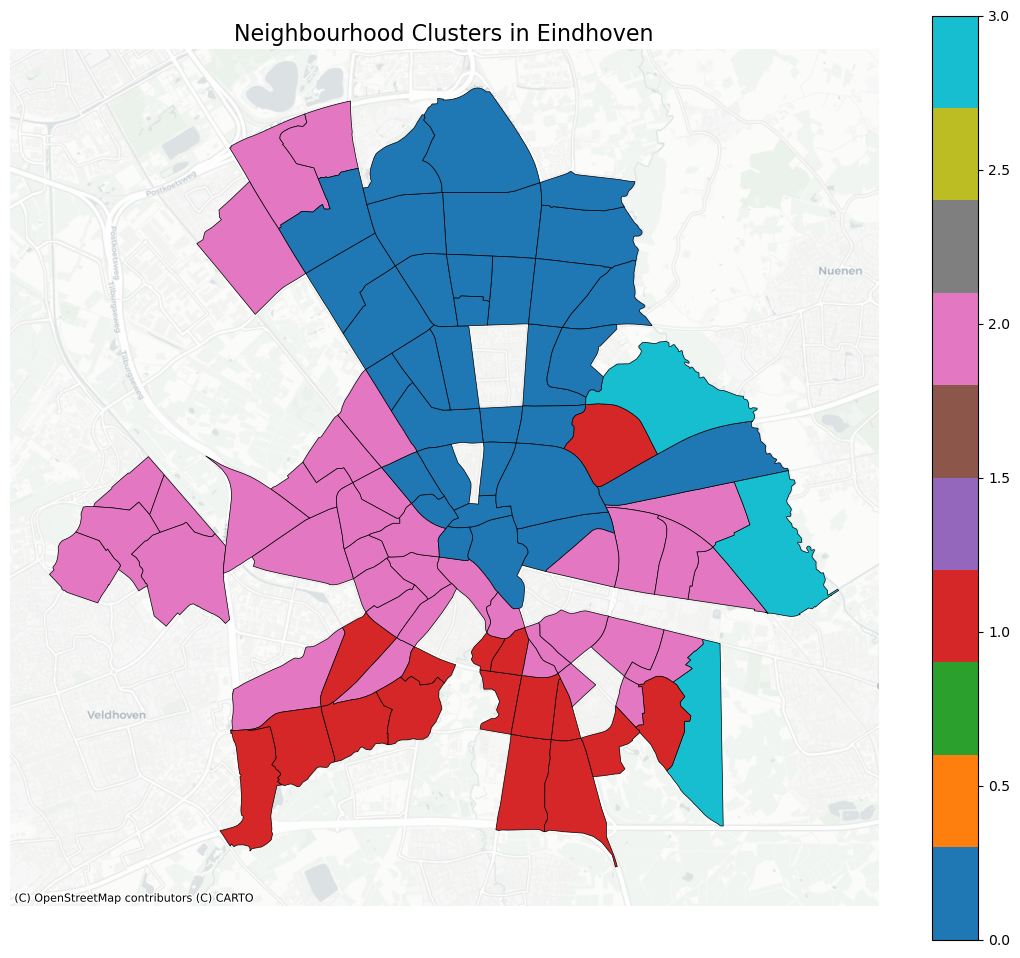

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
merged_gdf_3857.plot(
    column='cluster',
    cmap='tab10',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, alpha=0.8)
ax.set_title("Neighbourhood Clusters in Eindhoven", fontsize=16)
ax.set_axis_off()
plt.show()

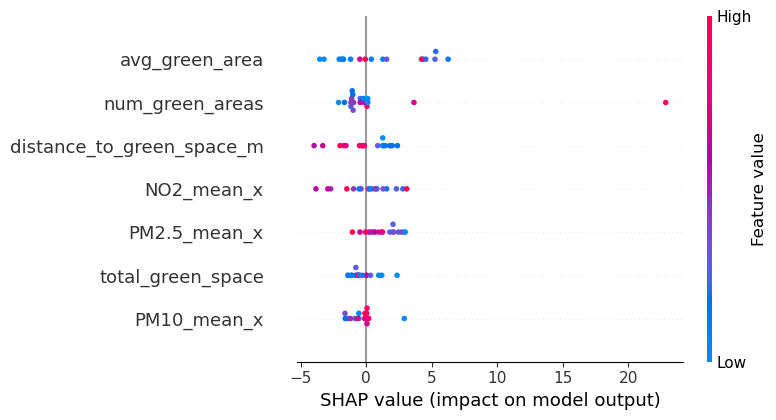

In [137]:
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

explainer = shap.Explainer(gb_model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, features=X_test, feature_names=features)

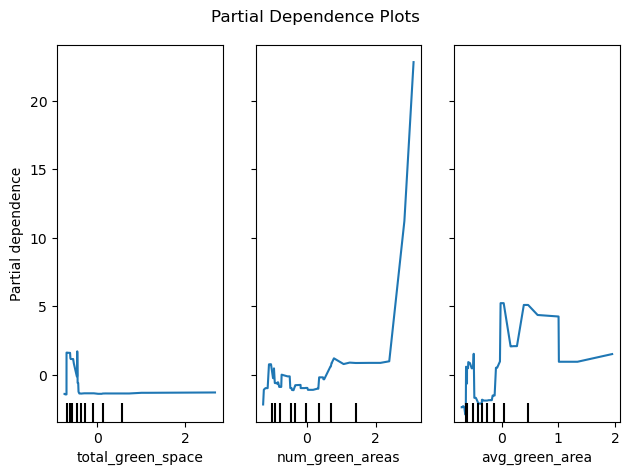

In [138]:
PartialDependenceDisplay.from_estimator(gb_model, X_train, features=[0, 1, 2], feature_names=features)
plt.suptitle("Partial Dependence Plots")
plt.tight_layout()
plt.show()

In [139]:
feature_names = X_train.columns if hasattr(X_train, 'columns') else features
i1 = feature_names.index("total_green_space")
i2 = feature_names.index("PM2.5_mean_x")

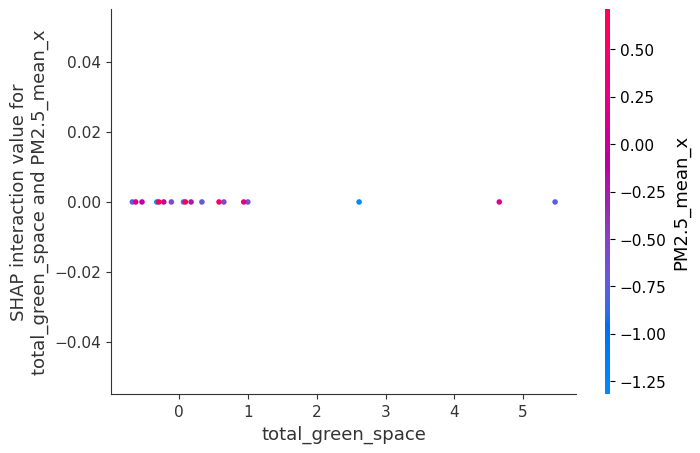

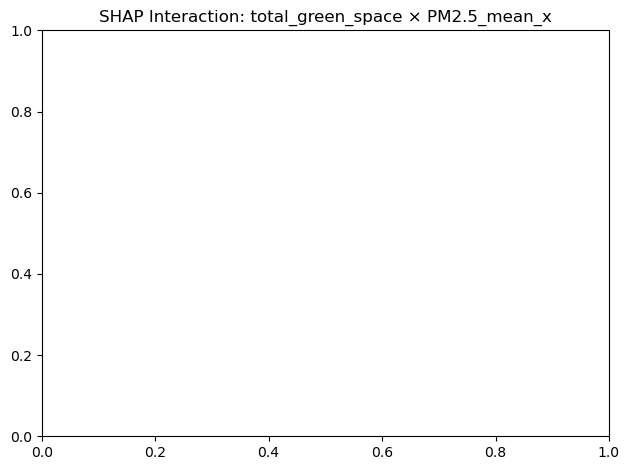

In [140]:
shap.dependence_plot(
    (i1, i2), explainer.shap_interaction_values(X_test), X_test,
    feature_names=feature_names,
    interaction_index=i2,
    show=True
)
plt.title(f"SHAP Interaction: {feature_names[i1]} × {feature_names[i2]}")
plt.tight_layout()
plt.show()

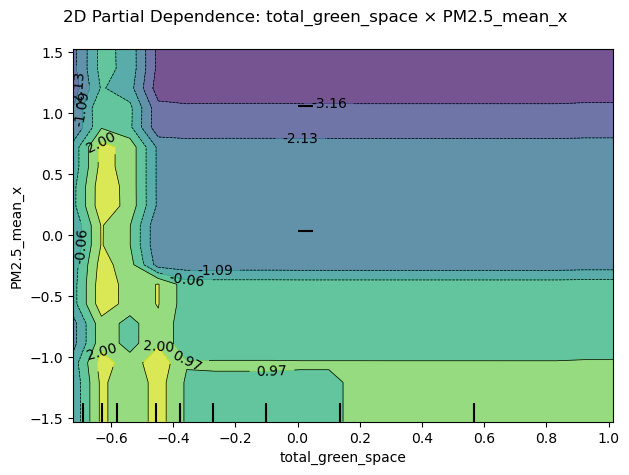

In [141]:
features_to_plot = [(i1, i2)]
disp = PartialDependenceDisplay.from_estimator(
    gb_model, X_train, features=features_to_plot,
    feature_names=feature_names, grid_resolution=20
)
plt.suptitle(f"2D Partial Dependence: {feature_names[i1]} × {feature_names[i2]}")
plt.tight_layout()
plt.show()

In [142]:
df['log_distance_to_green_space_m'] = np.log(df['distance_to_green_space_m'])

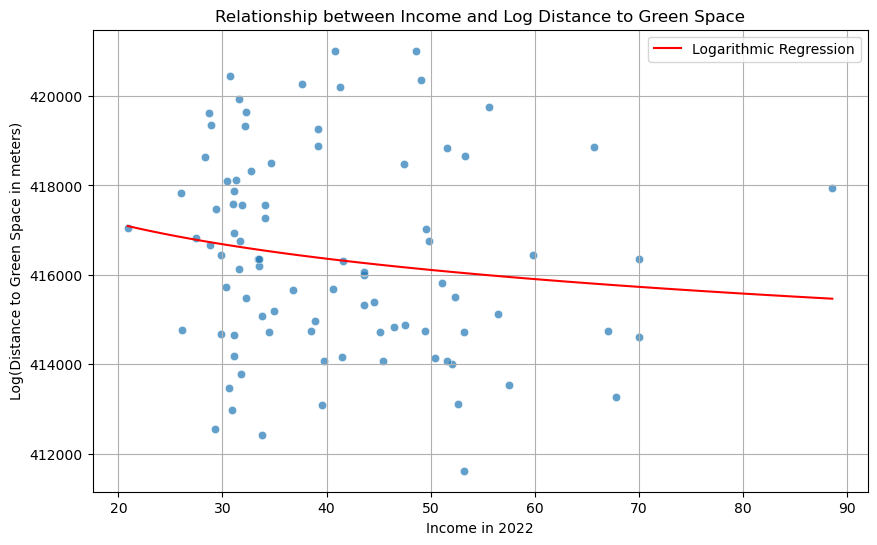

In [143]:
from scipy.optimize import curve_fit
import numpy as np

def log_func(x, a, b):
    return a * np.log(x) + b

df_plot = df[df['Income_2022'] > 0]

x = df_plot['Income_2022'].values
y = df_plot['distance_to_green_space_m'].values

params, _ = curve_fit(log_func, x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = log_func(x_fit, *params)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Income_2022', 
    y='distance_to_green_space_m', 
    data=df_plot,
    alpha=0.7
)
plt.plot(x_fit, y_fit, color='red', label='Logarithmic Regression')
plt.title('Relationship between Income and Log Distance to Green Space')
plt.xlabel('Income in 2022')
plt.ylabel('Log(Distance to Green Space in meters)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df_plot = df[df['Income_2022'] > 0]

x = df_plot['Income_2022'].values
y = df_plot['PM2.5_mean_x'].values

params, _ = curve_fit(log_func, x, y)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = log_func(x_fit, *params)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Income_2022', 
    y='PM2.5_mean_x', 
    data=df_plot,
    alpha=0.7
)
plt.plot(x_fit, y_fit, color='red', label='Logarithmic Regression')
plt.title('Relationship between Income and PM2.5')
plt.xlabel('Income in 2022')
plt.ylabel('Log(PM2.5)')
plt.grid(True)
plt.legend()
plt.show()

Slope (a): -0.2890
Standard error: 0.1796
t-statistic: -1.6093
p-value: 1.1118e-01
The slope is NOT statistically significant (p >= 0.05).
